In [ ]:
from pathlib import Path
import os, sys

# Ensure a common Results/ folder next to Experiments/
cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results directory: {OUT_DIR}")

In [10]:
%cd ..
%load_ext autoreload
%autoreload 2
from helpers.helpersGeneration import *
from helpers.helpersSimulation import *
from helpers.helpersTracking import *
from helpers.helpersStatistics import *
from helpers.helpersAssignment import *
from helpers.helpersPlotting import *

import copy
import pandas as pd
from pathlib import Path

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
simulation_config = {
    "n_ligands": 1,
    "n_receptors": 1,
    "nframes": 100,
    "nposframe": 10,
    "dt": 1.0,
    "ligand_D": [(4.0, 0.4), (6.0, 0.5), (8.0, 0.1)],
    "receptor_D": [(0.0, 0.3), (0.02, 0.7)],
    "frame_size": (128, 128),
    "boundary_margin": 50,
    "binding_radius": 4.0,
    "kon": 0.85,
    "koff": 0.02,
    "allow_multiple_ligands_per_receptor": False,
    "bound_position_noise": 0.15,
    "ligand_intensity_mean": 600,
    "ligand_intensity_std": 100,
    "receptor_intensity_mean": 750,
    "receptor_intensity_std": 200,
    "ligand_sigma_mean": 0.8,
    "ligand_sigma_std": 0.05,
    "receptor_sigma_mean": 1.0,
    "receptor_sigma_std": 0.1,
}

image_config = {
    "particle_intensity": [700, 300],
    "particle_sigma": [1.0, 0.2],
    "particle_type_props": {
        "ligand": {
            "particle_intensity": [750, 100],
            "particle_sigma": [1.0, 0.05],
        },
        "receptor": {
            "particle_intensity": [750, 200],
            "particle_sigma": [1.0, 0.08],
        },
    },
    "use_trajectory_sigma": True,
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim = LigandReceptorSimulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR
trajectories_GT = sim.trajectories_GT
ligands_GT = sim.get_ligands()
receptors_GT = sim.get_receptors()
binding_events = sim.binding_events
video_ligand_receptor = sim.video

In [12]:
print(f"Ligands: {len(ligands_GT)}")
print(f"Receptors: {len(receptors_GT)}")
print(f"Binding events: {len(binding_events)}")

if binding_events:
    durations = [event["end_subframe"] - event["start_subframe"] + 1 for event in binding_events]
    print(f"Mean bound duration: {np.mean(durations):.2f} subframes")
    print(binding_events[:5])

Ligands: 1
Receptors: 1
Binding events: 1
Mean bound duration: 235.00 subframes
[{'ligand_id': 1, 'receptor_id': 0, 'start_subframe': 765, 'end_subframe': 999, 'start_frame': 76, 'end_frame': 99}]


In [13]:
sim.animate(interval=100)

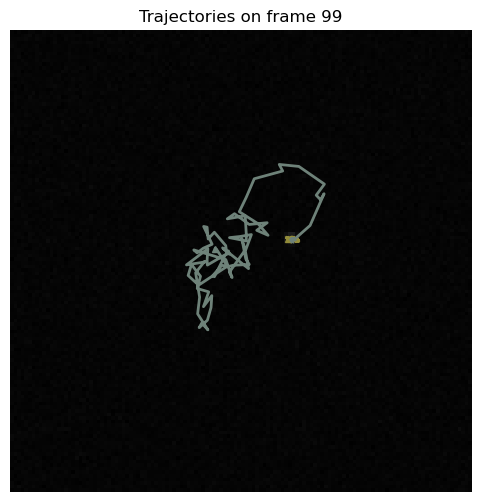

In [14]:
show_trajectories(frames, trajectories_GT, frame_id=simulation_config["nframes"]-1)

In [ ]:
# tracking


In [ ]:
linear_trajectories_visualizer(tra)